In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
import pingouin as pg

In [3]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/clean_inflation_df.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
wb_df = pd.read_csv(github_url)

In [4]:
#print the WB data frame shape
print("World Bank DataFrame Shape:", wb_df.shape)

World Bank DataFrame Shape: (12924, 25)


In [5]:
#check column names
print("World Bank DataFrame Columns:", wb_df.columns.tolist())

World Bank DataFrame Columns: ['country', 'code', 'region', 'income_group', 'lending_category', 'year', 'agricultural_land_pct', 'forest_land_pct', 'control_of_corruption_estimate', 'access_to_electricity_pct', 'renewable_energy_consumption_pct', 'co2_emissions', 'pop_density', 'inflation_yr_pct', 'tax_revenue_pct', 'gov_effectiveness_estimate', 'gdp_current_usd_M', 'political_stability_estimate', 'rule_of_law_estimate', 'gov_exp_on_education_pct', 'gov_health_exp_pct', 'life_expectancy_at_birth', 'pop_M', 'voice_and_accountability_estimate', 'co2_per_capita_t']


# CO2 and Renewables

#### Research Question:
Is there a correlation between CO2 emissions per capita and renewable energy consumption across different countries and times?

### Cleaning & Data Inspection


In [6]:
# Creating a subset with the relevant columns, i.e., 'country', 'code', 'region', 'year','co2_per_capita_t' and 'renewable_energy_consumption_pct'

wb_subset = wb_df[['country', 'code', 'region', 'year','co2_per_capita_t', 'renewable_energy_consumption_pct']]

In [9]:
# data inspection
wb_subset.info()
wb_subset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12924 entries, 0 to 12923
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country                           12924 non-null  object 
 1   code                              12924 non-null  object 
 2   region                            12924 non-null  object 
 3   year                              12924 non-null  int64  
 4   co2_per_capita_t                  12924 non-null  float64
 5   renewable_energy_consumption_pct  12924 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 605.9+ KB


/home/g3oplyr/miniconda3/envs/ASDA_2025/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,year,co2_per_capita_t,renewable_energy_consumption_pct
count,12924.000000,1.292400e+04,12924.000000
mean,1991.506577,inf,31.403374
std,18.525204,NaN,30.387340
min,1960.000000,0.000000e+00,0.000000
25%,1975.000000,8.729486e-01,4.697500
50%,1991.000000,3.249488e+00,20.095000
75%,2008.000000,7.907719e+00,54.280000
max,2023.000000,inf,98.270000


In [10]:
# drop rows in the subset where 'co2_per_capita_t' is infinite
wb_subset = wb_subset.replace([np.inf, -np.inf], np.nan).dropna(subset=['co2_per_capita_t'])

In [11]:
# converting 'year' to integer type
wb_subset['year'] = wb_subset['year'].astype(int)

In [12]:
# rounding 'renewable_energy_consumption_pct' to 2 decimal places
wb_subset['renewable_energy_consumption_pct'] = wb_subset['renewable_energy_consumption_pct'].round(2)

In [13]:
# rounding 'co2_per_capita_t' to 2 decimal places
wb_subset['co2_per_capita_t'] = wb_subset['co2_per_capita_t'].round(2)

In [15]:
wb_subset.head()


,country,code,region,year,co2_per_capita_t,renewable_energy_consumption_pct
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1960,0.24,25.54
1,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1961,0.23,25.54
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1962,0.23,25.54
3,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1963,0.22,25.54
4,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1964,0.22,25.54


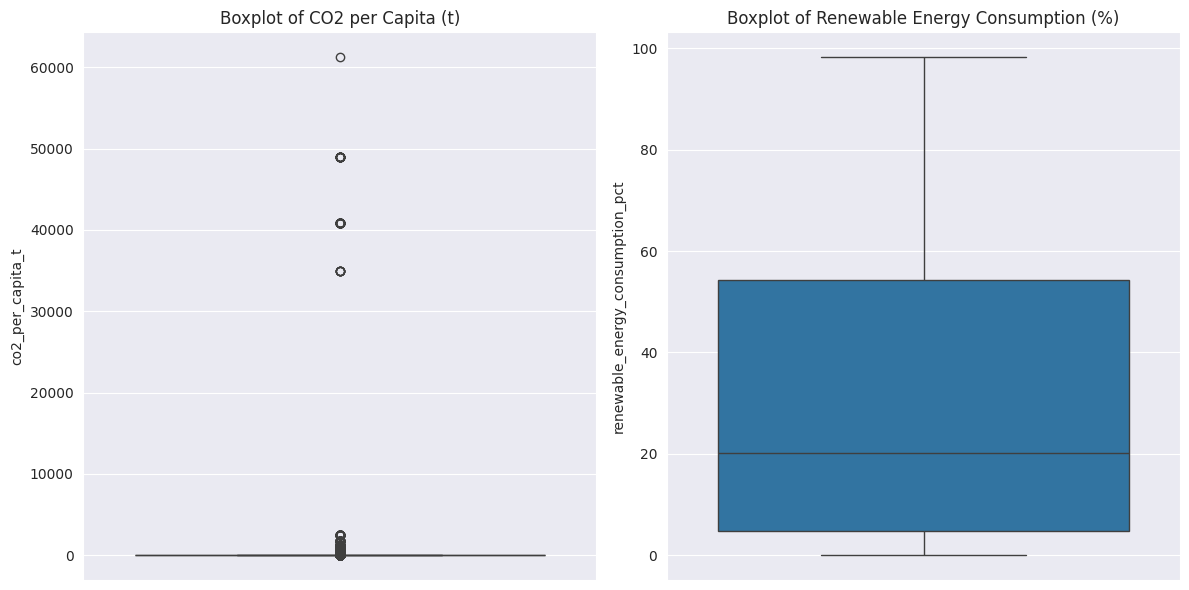

In [16]:
# inspecting outliers

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=wb_subset['co2_per_capita_t'])
plt.title('Boxplot of CO2 per Capita (t)')

plt.subplot(1, 2, 2)
sns.boxplot(y=wb_subset['renewable_energy_consumption_pct'])
plt.title('Boxplot of Renewable Energy Consumption (%)')
plt.tight_layout()
plt.show()

In [100]:
print(wb_subset['co2_per_capita_t'].quantile(0.999999999999999999999))

18.45


In [101]:
# removing outliers with values higher than the 99.9999999999999999999th percentile for 'co2_per_capita_t'
threshold_co2 = 18.45
wb_subset = wb_subset[wb_subset['co2_per_capita_t'] <= threshold_co2]

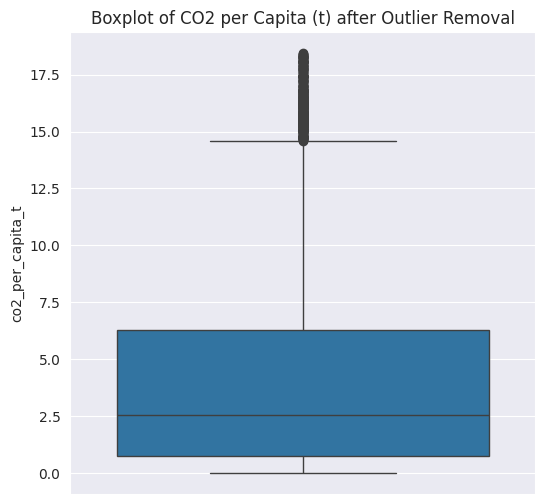

In [102]:
# showing co2 boxplot after outlier removal

plt.figure(figsize=(6, 6))
sns.boxplot(y=wb_subset['co2_per_capita_t'])
plt.title('Boxplot of CO2 per Capita (t) after Outlier Removal')
plt.show()

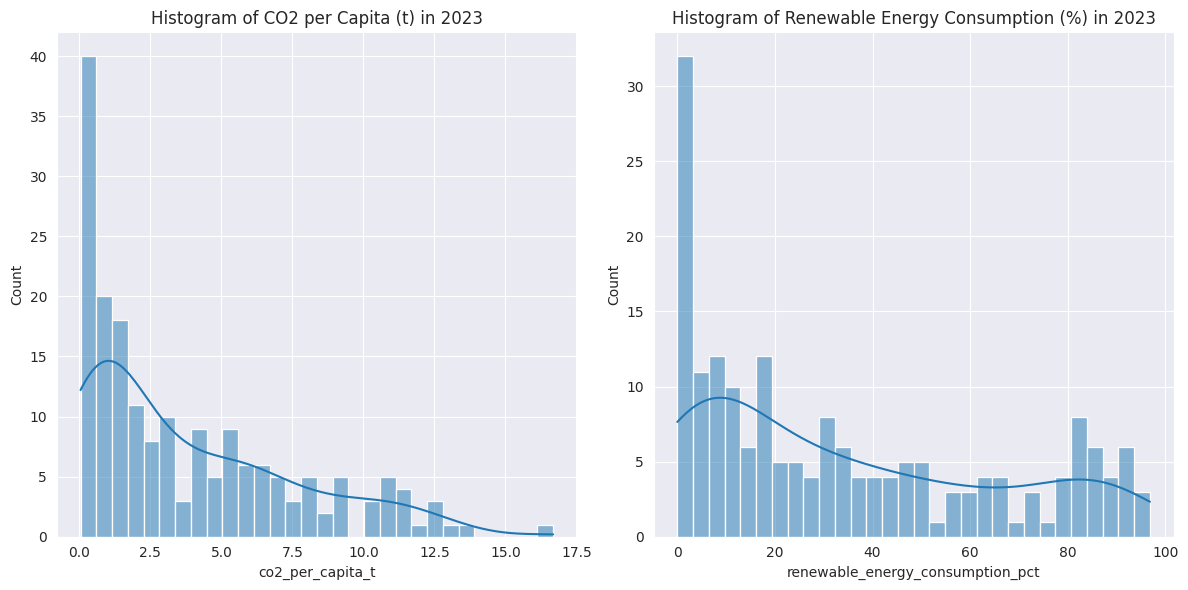

In [112]:
# only histogram for year 2023
wb_2023 = wb_subset[wb_subset['year'] == 2023]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(wb_2023['co2_per_capita_t'], bins=30, kde=True)
plt.title('Histogram of CO2 per Capita (t) in 2023')
plt.subplot(1, 2, 2)
sns.histplot(wb_2023['renewable_energy_consumption_pct'], bins=30, kde=True)
plt.title('Histogram of Renewable Energy Consumption (%) in 2023')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7092/2260705464.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wb_2023['co2_per_capita_t_log'] = wb_2023['co2_per_capita_t'].apply(lambda x: math.log(x + 1))  # adding 1 to avoid log(0)


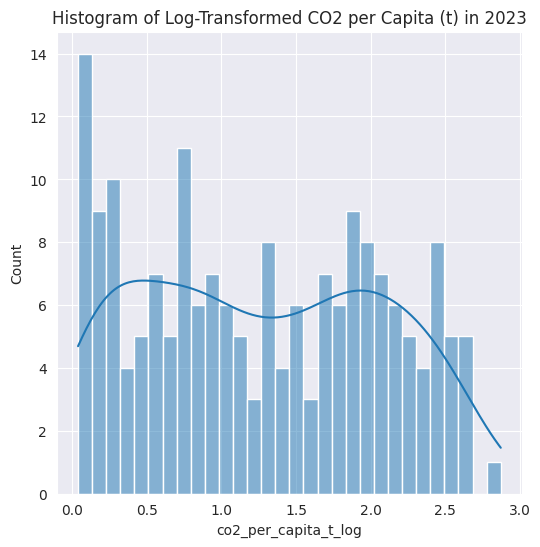

In [113]:
# again poisson distributed, hence log transformation
wb_2023['co2_per_capita_t_log'] = wb_2023['co2_per_capita_t'].apply(lambda x: math.log(x + 1))  # adding 1 to avoid log(0)

# plotting histogram of log-transformed co2_per_capita_t for year 2023
plt.figure(figsize=(6, 6))
sns.histplot(wb_2023['co2_per_capita_t_log'], bins=30, kde=True)
plt.title('Histogram of Log-Transformed CO2 per Capita (t) in 2023')
plt.show()

#### Commentary
In order to proceed with the analysis, a subset was created, the data types were adjusted, and outliers (> 18.45 t CO2 per capita) were removed from the co2_per_capita column.

### Global Trend


In [47]:
# reading global countries shapefile data from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
gdf = gpd.read_file(github_url)

In [48]:
# plotting world map with CO2 per capita and renewable energy consumption for the year 2023
import geopandas as gpd
# merging world map data with wb_subset for the year 2023
wb_2023 = wb_subset[wb_subset['year'] == 2023]
world = gdf.merge(wb_2023, left_on='ADM0_A3', right_on='code', how='left')

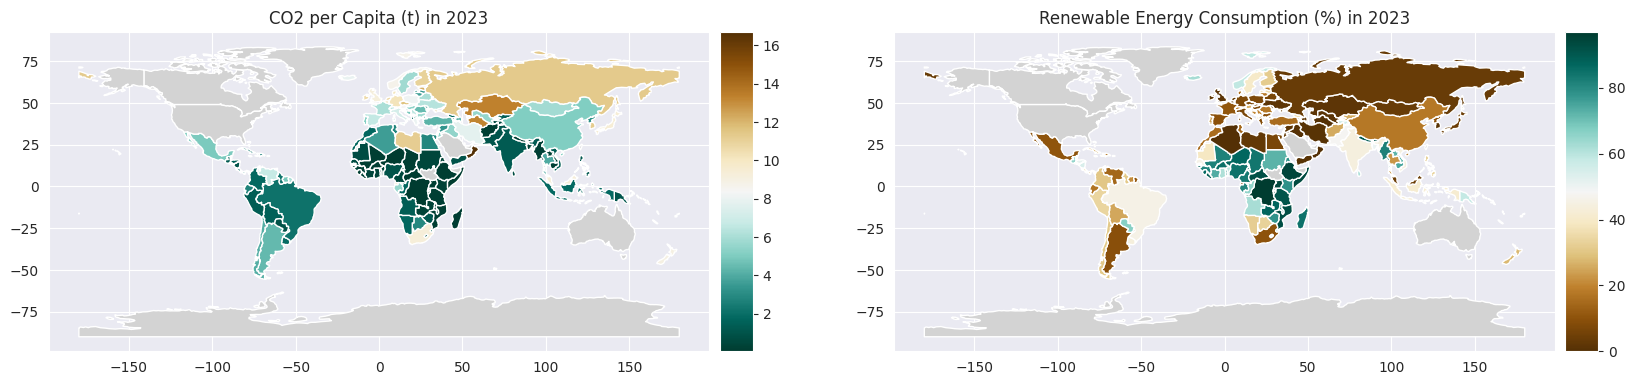

In [71]:
# plotting two subsets with each a world map; one for Co2 per capita and one for renewable energy consumption; and in sucvh a way that colorbars align with the maps

from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# plotting CO2 per capita
world.plot(column='co2_per_capita_t', ax=ax[0], cmap='BrBG_r', missing_kwds={"color": "lightgrey"})
ax[0].set_title('CO2 per Capita (t) in 2023')
divider0 = make_axes_locatable(ax[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.1)
sm0 = plt.cm.ScalarMappable(cmap='BrBG_r', norm=plt.Normalize(vmin=world['co2_per_capita_t'].min(), vmax=world['co2_per_capita_t'].max()))
sm0._A = []
fig.colorbar(sm0, cax=cax0)

# plotting renewable energy consumption
world.plot(column='renewable_energy_consumption_pct', ax=ax[1], cmap='BrBG', missing_kwds={"color": "lightgrey"})
ax[1].set_title('Renewable Energy Consumption (%) in 2023')
divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
sm1 = plt.cm.ScalarMappable(cmap='BrBG', norm=plt.Normalize(vmin=world['renewable_energy_consumption_pct'].min(), vmax=world['renewable_energy_consumption_pct'].max()))
sm1._A = []
fig.colorbar(sm1, cax=cax1)
plt.show()

#### Commentary
The two world maps show opposing trends: In the Global North high CO2 per capita emissions are observed while renewable energy consumption is, relatively speaking, low. In contrast, in the Global South, and especially in sub-Saharan Africa, low CO2 emissions and moderate to high renewable energy consumption are seen.

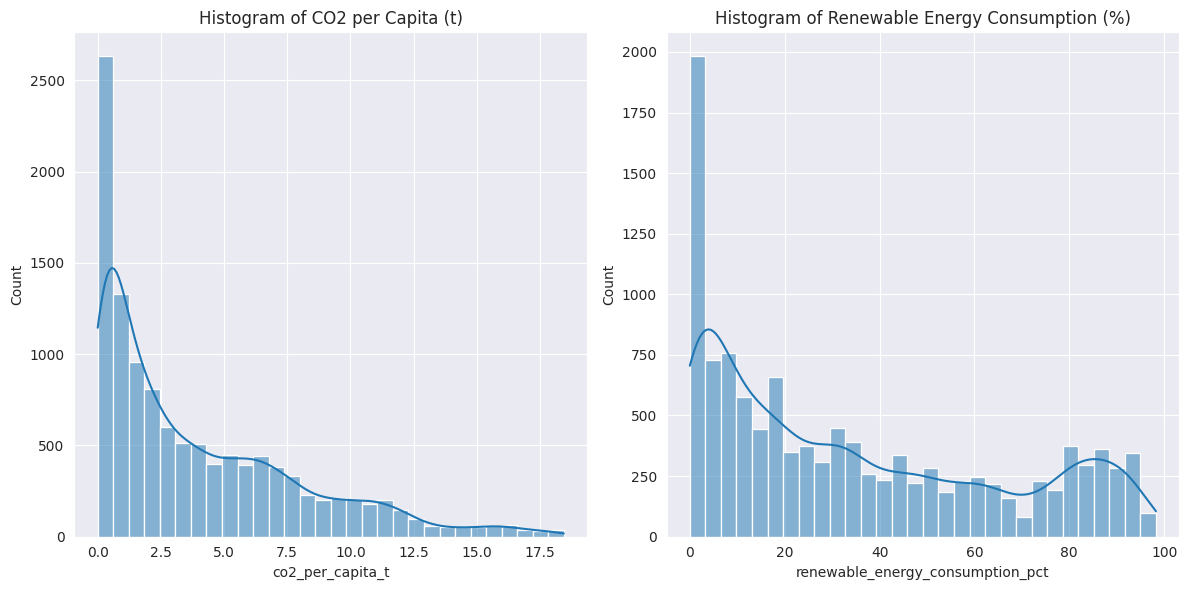

In [114]:
# plotting both, co2_per_capita_t and renewable_energy_consumption_pct, as histograms
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(wb_subset['co2_per_capita_t'], bins=30, kde=True)
plt.title('Histogram of CO2 per Capita (t)')
plt.subplot(1, 2, 2)
sns.histplot(wb_subset['renewable_energy_consumption_pct'], bins=30, kde=True)
plt.title('Histogram of Renewable Energy Consumption (%)')
plt.tight_layout()
plt.show()

In [117]:
# due to probably poisson distributed data of co2_per_capita_t, applying log transformation for better visualization in scatterplots
wb_subset['co2_per_capita_t_log'] = wb_subset['co2_per_capita_t'].apply(lambda x: math.log(x + 1))  # adding 1 to avoid log(0)

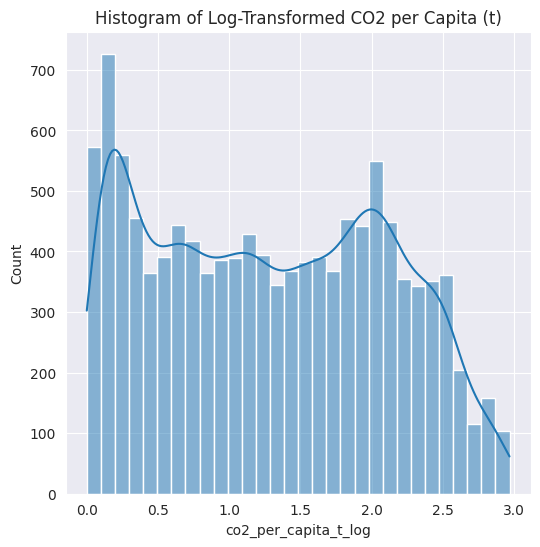

In [116]:
# plotting histogram of log-transformed co2_per_capita_t

plt.figure(figsize=(6, 6))
sns.histplot(wb_subset['co2_per_capita_t_log'], bins=30, kde=True)
plt.title('Histogram of Log-Transformed CO2 per Capita (t)')
plt.show()

#### Commentary: As the data is not normally distributed, the Spearman's correlation coefficient will be used for the correlation analysis.

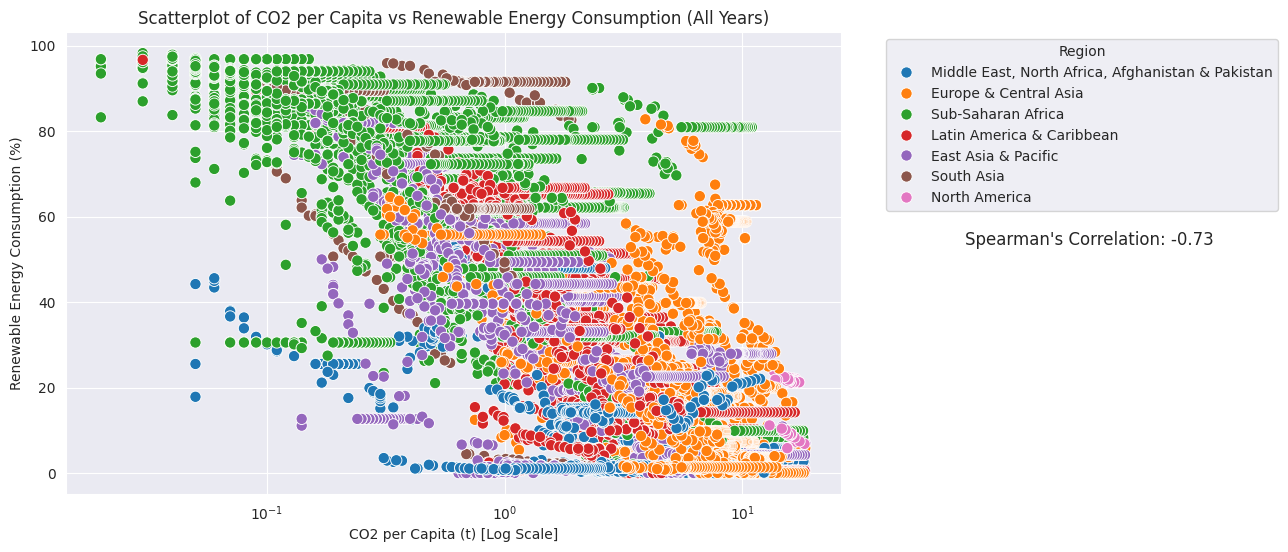

In [120]:
# Correlation analysis between CO2 per capita and renewable energy consumption for the complete time period: Scatterplot with points coloured by region, log scale for x axis, and spearman's correlation coefficient

plt.figure(figsize=(10, 6))
sns.scatterplot(data=wb_subset, x='co2_per_capita_t', y='renewable_energy_consumption_pct', hue='region', s=66)
plt.xscale('log')
corr = wb_subset[['co2_per_capita_t', 'renewable_energy_consumption_pct']].corr(method='spearman').iloc[0,1]
plt.title('Scatterplot of CO2 per Capita vs Renewable Energy Consumption (All Years)')
plt.xlabel('CO2 per Capita (t) [Log Scale]')
plt.ylabel('Renewable Energy Consumption (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.text(1.16, 0.57, f"Spearman's Correlation: {corr:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.show()

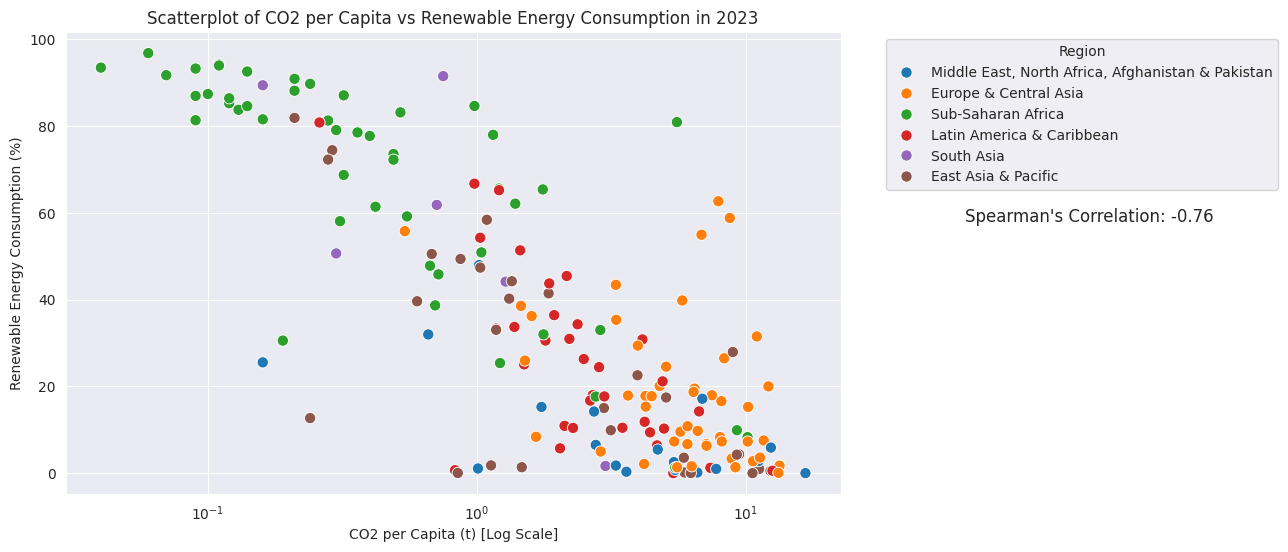

In [119]:
# Correlation analysis between CO2 per capita and renewable energy consumption for the year 2023: Scatterplot with points coloured by region, log scale for x axis, and spearman's correlation coefficient

plt.figure(figsize=(10, 6))
sns.scatterplot(data=wb_2023, x='co2_per_capita_t', y='renewable_energy_consumption_pct', hue='region', s=66)
plt.xscale('log')
corr = wb_2023[['co2_per_capita_t', 'renewable_energy_consumption_pct']].corr(method='spearman').iloc[0,1]
plt.title('Scatterplot of CO2 per Capita vs Renewable Energy Consumption in 2023')
plt.xlabel('CO2 per Capita (t) [Log Scale]')
plt.ylabel('Renewable Energy Consumption (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.text(1.16, 0.62, f"Spearman's Correlation: {corr:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.show()

### Case Study: Germany

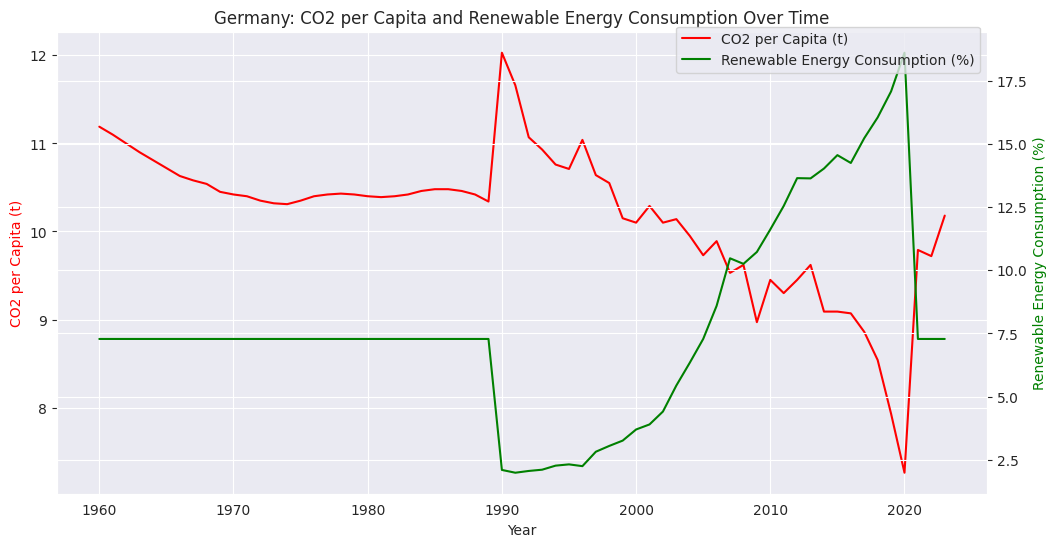

In [52]:
#plotting time series of CO2 per capita and renewable energy consumption for Germany

germany_data = wb_subset[wb_subset['country'] == 'Germany']
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(germany_data['year'], germany_data['co2_per_capita_t'], color='r', label='CO2 per Capita (t)')
ax2.plot(germany_data['year'], germany_data['renewable_energy_consumption_pct'], color='g', label='Renewable Energy Consumption (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 per Capita (t)', color='r')
ax2.set_ylabel('Renewable Energy Consumption (%)', color='g')
plt.title('Germany: CO2 per Capita and Renewable Energy Consumption Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

In [ ]:
# for more details, only the decades from 1990 to 2020 are shown; the other years are excluded due to the fact that there was missing data that was replaced by averages

germany_case_data = germany_data[(germany_data['year'] >= 1990) & (germany_data['year'] <= 2020)]

In [ ]:
# correlating (Spearman's)

corr = germany_case_data[['co2_per_capita_t', 'renewable_energy_consumption_pct']].corr(method='spearman').iloc[0,1]

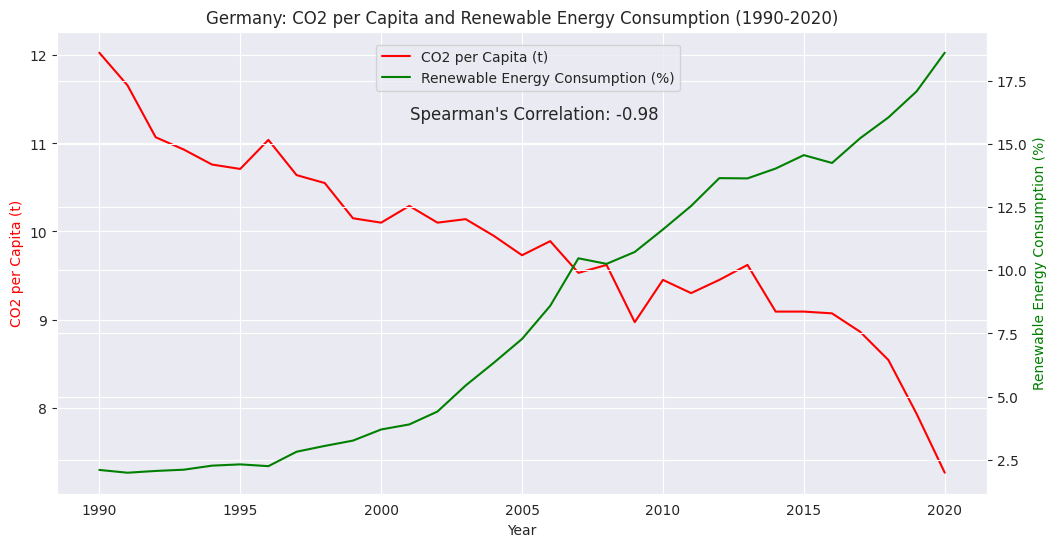

In [67]:
# plotting time series for the period 1990-2020

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(germany_case_data['year'], germany_case_data['co2_per_capita_t'], color='r', label='CO2 per Capita (t)')
ax2.plot(germany_case_data['year'], germany_case_data['renewable_energy_consumption_pct'], color='g', label='Renewable Energy Consumption (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 per Capita (t)', color='r')
ax2.set_ylabel('Renewable Energy Consumption (%)', color='g')
plt.title('Germany: CO2 per Capita and Renewable Energy Consumption (1990-2020)')
fig.legend(loc='upper right', bbox_to_anchor=(0.65, 0.87))
plt.text(0.38, 0.84, f"Spearman's Correlation: {corr:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.show()

### Commentary
As can be seen in the figure, Germany has experienced a steady decrease in CO2 emissions while investing in renewable energy. The correlation is very high. This clear trend seems to reflect the country's ambition regarding energy transition ("Energiewende") in face of climate change and, hence, even a causality might be implied here. However, this cannot be understood from the data alone but needs further research.